#pandas ile bilgi.xlsx veriyi import edelim.

In [ ]:
# TR_ABDOMEN_BASE=D:/makale-pdf/Proje/abdomen
# TR_ABDOMEN_PROJE=D:/makale-pdf/Proje
# TR_ABDOMEN_CODE=D:/makale-pdf/Proje/code
# ABDOMEN_PROJECT_ROOT=D:/makale-pdf/Proje
# ABDOMEN_DATA_ROOT=D:/makale-pdf/Proje/abdomen
# ABDOMEN_TRAIN_DIR=D:/makale-pdf/Proje/abdomen/Eğitim Verisi
# ABDOMEN_TEST_DIR=D:/makale-pdf/Proje/abdomen/Test Verisi
# ABDOMEN_BILGI_XLSX=D:/makale-pdf/Proje/abdomen/Bilgi.xlsx
# ABDOMEN_OUT_DIR=D:/makale-pdf/Proje/outputs
# ABDOMEN_SPLIT_DIR=D:/makale-pdf/Proje/outputs/splits
# ABDOMEN_CLS_DATA_DIR=D:/makale-pdf/Proje/outputs/cls_data
# ABDOMEN_DET_DATA_DIR=D:/makale-pdf/Proje/outputs/det_data
# ABDOMEN_SEG_DATA_DIR=D:/makale-pdf/Proje/outputs/seg_data
# ABDOMEN_CKPT_DIR=D:/makale-pdf/Proje/outputs/checkpoints
# ABDOMEN_LOG_DIR=D:/makale-pdf/Proje/outputs/logs    

In [ ]:
# !pip install openpyxl python-dotenv
# !pip install seaborn

In [ ]:
import numpy as np

In [2]:
import pandas as pd
import matplotlib.patches as patches
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pydicom


In [3]:
from pathlib import Path
import os
from dotenv import load_dotenv

In [4]:
# ---- YOLLAR ----


# .env dosyasını yükle ve varsa TR_ABDOMEN_BASE değerini çevresel değişken olarak al.
load_dotenv()

# Ortam değişkeni ile temel klasör tanımı.
# Eğer TR_ABDOMEN_BASE ortam değişkeni veya .env içinde tanımı varsa onu kullan, yoksa varsayılan yolu kullan.
BASE = Path(os.environ.get(
    "TR_ABDOMEN_BASE",
    r"/Users/ramazanpolat/Desktop/datasets/abdomen"
))

XLSX = BASE / "Bilgi.xlsx"
DIRS = {
    "Eğitim": BASE / "Eğitim Verisi",
    "Yarışma": BASE / "Yarışma Veri Seti",
}
TRAIN_DIR = DIRS["Eğitim"]
TEST_DIR = DIRS["Yarışma"]

OUT = BASE / "Analiz_Sonuclari" / "grafikler" / "sinif_ornekleri_bb.png"

sheets = pd.read_excel(XLSX, sheet_name=None)

In [5]:
# =========================================================
# 1) ANNOTASYONLU KESİT SAYISI (Bilgi.xlsx'ten)
#    Her vakada KAÇ tekil Image Id annotasyonlu? Medyanı al.
# =========================================================

print("=" * 60)
print("Vaka başına ANNOTASYONLU KESİT sayısı (Bilgi.xlsx)")
print("=" * 60)
 
for sheet_name, df in sheets.items():
    # Her Case Number için kaç farklı Image Id annotasyonlu?
    annotated_per_case = df.groupby("Case Number")["Image Id"].nunique()
 
    print(f"\n--- {sheet_name} ---")
    print(f"  Vaka sayısı           : {len(annotated_per_case)}")
    print(f"  Medyan (annotasyonlu) : {int(annotated_per_case.median())}")
    print(f"  Ortalama              : {annotated_per_case.mean():.1f}")
    print(f"  Min / Max             : {annotated_per_case.min()} / {annotated_per_case.max()}")

Vaka başına ANNOTASYONLU KESİT sayısı (Bilgi.xlsx)

--- COMPETITIONDATA ---
  Vaka sayısı           : 357
  Medyan (annotasyonlu) : 29
  Ortalama              : 37.5
  Min / Max             : 9 / 399

--- TRAIININGDATA ---
  Vaka sayısı           : 735
  Medyan (annotasyonlu) : 19
  Ortalama              : 35.2
  Min / Max             : 3 / 283


In [6]:

# =========================================================
# 2) TOPLAM DICOM KESİT SAYISI (dosya sisteminden)
#    Her vaka klasöründeki .dcm dosya sayısı. Medyan + maks.
# =========================================================
print("\n" + "=" * 60)
print("Vaka başına TOPLAM DICOM kesit sayısı (dosya sistemi)")
print("=" * 60)
 
for label, root in DIRS.items():
    # Her vaka klasöründeki .dcm sayısını topla
    counts = []
    for case_dir in sorted(root.iterdir()):
        if case_dir.is_dir():
            n_dcm = sum(1 for f in case_dir.iterdir() if f.suffix.lower() == ".dcm")
            counts.append(n_dcm)
 
    s = pd.Series(counts)
    print(f"\n--- {label} ({root.name}) ---")
    print(f"  Vaka sayısı          : {len(s)}")
    print(f"  Toplam DICOM kesit   : {s.sum():,}")
    print(f"  Medyan (kesit/vaka)  : {int(s.median())}")
    print(f"  Ortalama             : {s.mean():.1f}")
    print(f"  Maksimum (kesit/vaka): {s.max()}")
    print(f"  Minimum              : {s.min()}")


Vaka başına TOPLAM DICOM kesit sayısı (dosya sistemi)

--- Eğitim (Eğitim Verisi) ---
  Vaka sayısı          : 1
  Toplam DICOM kesit   : 0
  Medyan (kesit/vaka)  : 0
  Ortalama             : 0.0
  Maksimum (kesit/vaka): 0
  Minimum              : 0


FileNotFoundError: [WinError 3] Sistem belirtilen yolu bulamıyor: 'D:\\makale-pdf\\Proje\\abdomen\\Yarışma Veri Seti'

In [7]:
#pandas ile bilgi.xlsx veriyi import edelim.
dataTrain = pd.read_excel('bilgi.xlsx', sheet_name='TRAIININGDATA')
#Verinin ilk 5 satırına bakalım.
dataTrain.head()

,Case Number,Image Id,Type,Class,Data
0,20001,100007,Bounding Box,ureteral stone,"251,290-262,302"
1,20001,100008,Bounding Box,ureteral stone,"251,291-261,301"
2,20001,100010,Boundary Slice,Kidney-Bladder,NaN
3,20002,100070,Boundary Slice,Kidney-Bladder,NaN
4,20002,100120,Bounding Box,Kidney stone,"337,276-345,282"


In [8]:
#pandas ile bilgi.xlsx veriyi import edelim.
dataTest = pd.read_excel('bilgi.xlsx', sheet_name='COMPETITIONDATA')
#Verinin ilk 5 satırına bakalım.
dataTest.head()

,Case Number,Image Id,Type,Class,Data
0,20001,100014,Boundary Slice,Colon,0
1,20001,100017,Boundary Slice,Abdominal Aorta,0
2,20001,100018,Boundary Slice,Pancreas,0
3,20001,100019,Boundary Slice,Gall bladder,0
4,20001,100021,Boundary Slice,Kidney-Bladder,0


In [9]:
dataTest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14314 entries, 0 to 14313
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Case Number  14314 non-null  int64 
 1   Image Id     14314 non-null  int64 
 2   Type         14314 non-null  object
 3   Class        14314 non-null  object
 4   Data         14314 non-null  object
dtypes: int64(2), object(3)
memory usage: 559.3+ KB


In [10]:
dataTest.isnull().sum()

Case Number    0
Image Id       0
Type           0
Class          0
Data           0
dtype: int64

In [11]:
#type sütununda kaç farklı tür olduğunu görelim.
dataTest['Type'].value_counts()

Type
Bounding Box      10052
Boundary Slice     4262
Name: count, dtype: int64

In [12]:
#Class sütununda kaç farklı tür olduğunu görelim.
dataTest['Class'].value_counts()

Class
Abdominal aortic aneurysm               2875
Compatible with acute pancreatitis      2335
Compatible with acute appendicitis      2229
Compatible with acute cholecystitis     1262
Kidney stone                            1029
Colon                                    714
Kidney-Bladder                           714
Abdominal Aorta                          710
Pancreas                                 708
Gall bladder                             708
appendix                                 708
Compatible with acute diverticulitis     322
Name: count, dtype: int64

In [13]:
#Class sütununda kaç farklı tür olduğunu görelim.
dataTrain['Class'].value_counts()

Class
Abdominal aortic aneurysm               8983
Compatible with acute pancreatitis      7128
Compatible with acute cholecystitis     5159
Gallbladder stone                       1439
Kidney stone                            1149
Abdominal aortic dissection              806
Abdominal Aorta                          733
Kidney-Bladder                           608
Pancreas                                 502
Gall bladder                             439
Colon                                    411
appendix                                 338
ureteral stone                           321
Compatible with acute appendicitis        60
Calcified diverticulum                    38
Compatible with acute diverticulitis      20
Name: count, dtype: int64

In [14]:
#test ve train veri setleri için Vaka (case) sayısına bakalım.
print("Train veri setindeki vaka sayısı:", dataTrain['Case Number'].nunique())
print("Test veri setindeki vaka sayısı:", dataTest['Case Number'].nunique())

Train veri setindeki vaka sayısı: 735
Test veri setindeki vaka sayısı: 357


In [15]:
#Tekil annotasyonlu kesit sayısına bakalım.
print("Train veri setindeki tekil annotasyonlu kesit sayısı:", dataTrain['Image Id'].nunique())
print("Test veri setindeki tekil annotasyonlu kesit sayısı:", dataTest['Image Id'].nunique())

Train veri setindeki tekil annotasyonlu kesit sayısı: 25886
Test veri setindeki tekil annotasyonlu kesit sayısı: 13382


In [16]:
#Annotasyon satırı sayısına bakalım.
print("Train veri setindeki annotasyon satırı sayısı:", len(dataTrain))
print("Test veri setindeki annotasyon satırı sayısı:", len(dataTest))

Train veri setindeki annotasyon satırı sayısı: 28134
Test veri setindeki annotasyon satırı sayısı: 14314


In [17]:
#Vaka başına annotasyonlu kesit (medyan) sayısına bakalım.
train_case_annotation_counts = dataTrain.groupby('Case Number')['Image Id'].nunique()
test_case_annotation_counts = dataTest.groupby('Case Number')['Image Id'].nunique()
print("Train veri setindeki vaka başına annotasyonlu kesit sayısının medyanı:", train_case_annotation_counts.median())
print("Test veri setindeki vaka başına annotasyonlu kesit sayısının medyanı:", test_case_annotation_counts.median())

Train veri setindeki vaka başına annotasyonlu kesit sayısının medyanı: 19.0
Test veri setindeki vaka başına annotasyonlu kesit sayısının medyanı: 29.0


In [18]:
#VVaka başına toplam DICOM kesit (medyan) sayısına bakalım.
train_case_annotation_counts = dataTrain.groupby('Case Number')['Image Id']
test_case_annotation_counts = dataTest.groupby('Case Number')['Image Id']
print("Train veri setindeki vaka başına annotasyonlu kesit sayısının medyanı:", len(train_case_annotation_counts))
print("Test veri setindeki vaka başına annotasyonlu kesit sayısının medyanı:", len(test_case_annotation_counts))

Train veri setindeki vaka başına annotasyonlu kesit sayısının medyanı: 735
Test veri setindeki vaka başına annotasyonlu kesit sayısının medyanı: 357


In [19]:
#Kritik gözlem 1 — Sınıf eşleşmemesi: 

#Eğitim setinde olan ama test setinde olmayan sınıflar var mı? Varsa hangileri?
train_classes = set(dataTrain['Class'].unique())
test_classes = set(dataTest['Class'].unique())
unmatched_classes = train_classes - test_classes
print("Eğitim setinde olan ama test setinde olmayan sınıflar:", unmatched_classes)
#test veri setinde eğitim setinde olmayan sınıflar var mı? Varsa hangileri?
unmatched_classes_test = test_classes - train_classes
print("Test setinde olan ama eğitim setinde olmayan sınıflar:", unmatched_classes_test)


Eğitim setinde olan ama test setinde olmayan sınıflar: {'ureteral stone', 'Abdominal aortic dissection', 'Calcified diverticulum', 'Gallbladder stone'}
Test setinde olan ama eğitim setinde olmayan sınıflar: set()


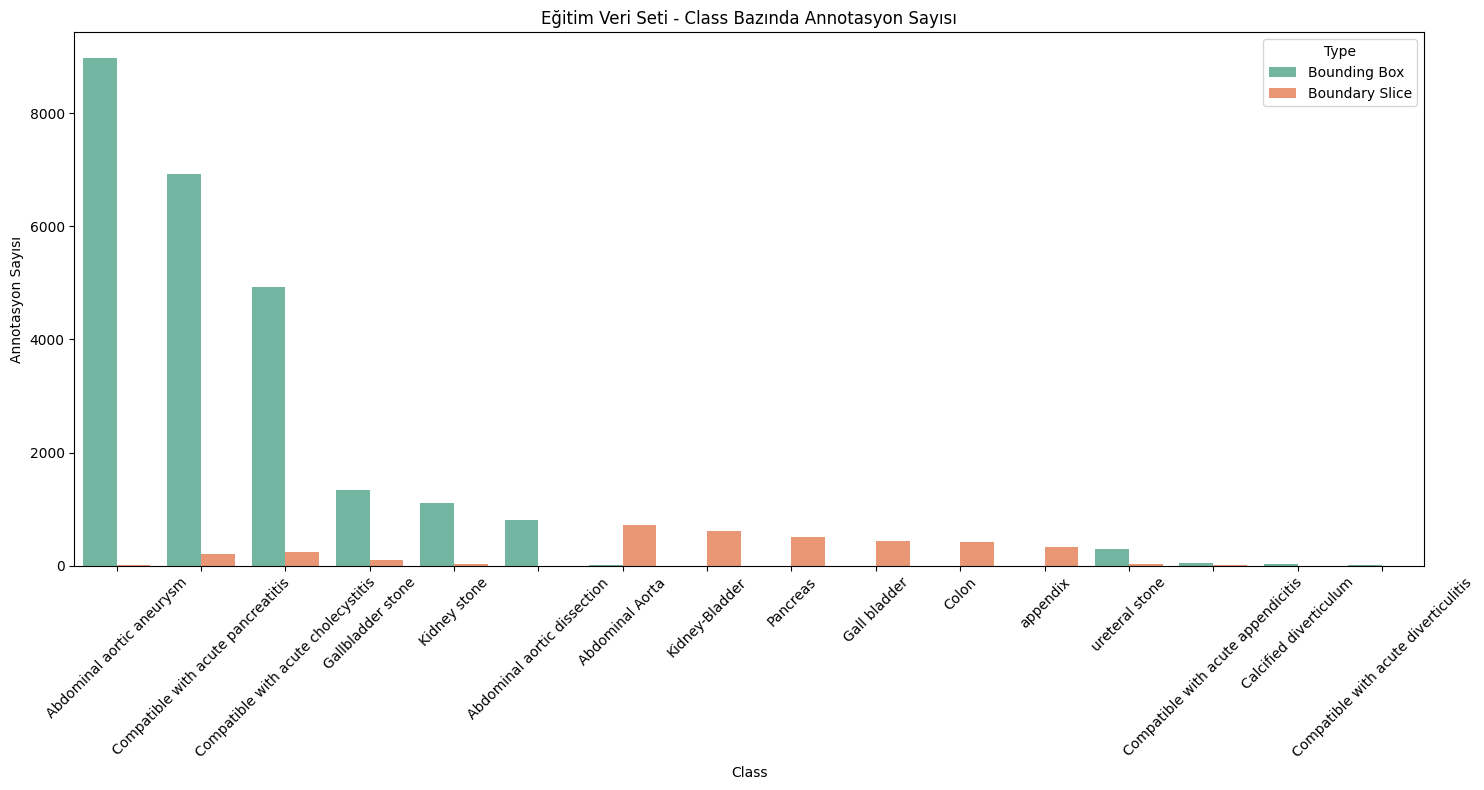

In [20]:
#Eğitim veri setinde Sınıf bazında Annotasyon sayısı grafını çizelim.
plt.figure(figsize=(15, 8))
sns.countplot(x='Class', data=dataTrain,order=dataTrain['Class'].value_counts().index,legend=True, hue='Type',palette='Set2')
plt.title('Eğitim Veri Seti - Class Bazında Annotasyon Sayısı')
plt.xlabel('Class')
plt.ylabel('Annotasyon Sayısı')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

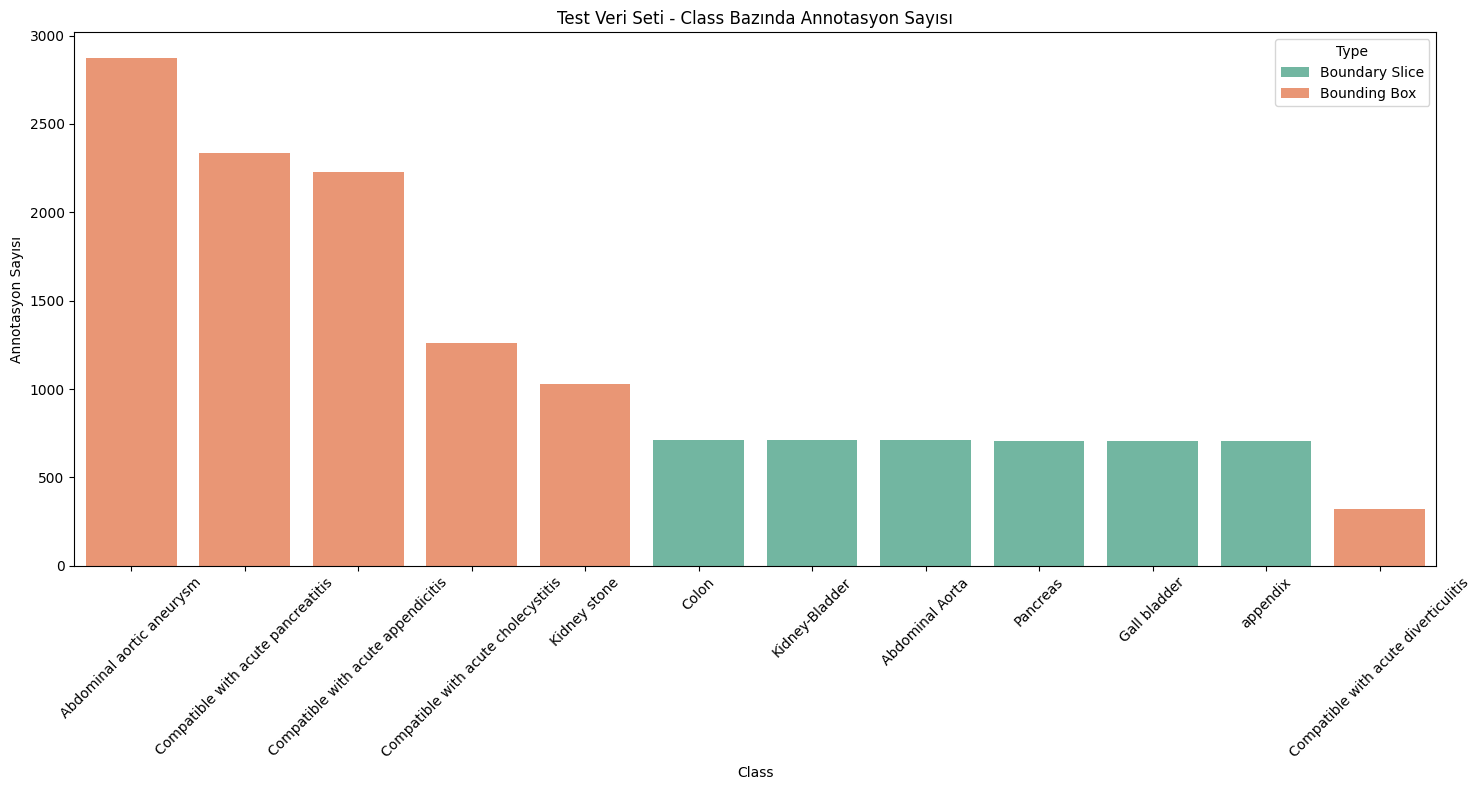

In [21]:
#Test veri setinde Sınıf bazında Annotasyon sayısı grafını çizelim.
plt.figure(figsize=(15, 8))
sns.countplot(x='Class', data=dataTest,order=dataTest['Class'].value_counts().index,legend=True, hue='Type',palette='Set2')
plt.title('Test Veri Seti - Class Bazında Annotasyon Sayısı')
plt.xlabel('Class')
plt.ylabel('Annotasyon Sayısı')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\ramazan.polat3\AppData\Local\Temp\ipykernel_23964\917787825.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Type', data=dataTrain,order=dataTrain['Type'].value_counts().index,palette='Set2')
C:\Users\ramazan.polat3\AppData\Local\Temp\ipykernel_23964\917787825.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Type', data=dataTest,order=dataTest['Type'].value_counts().index,palette='Set2')


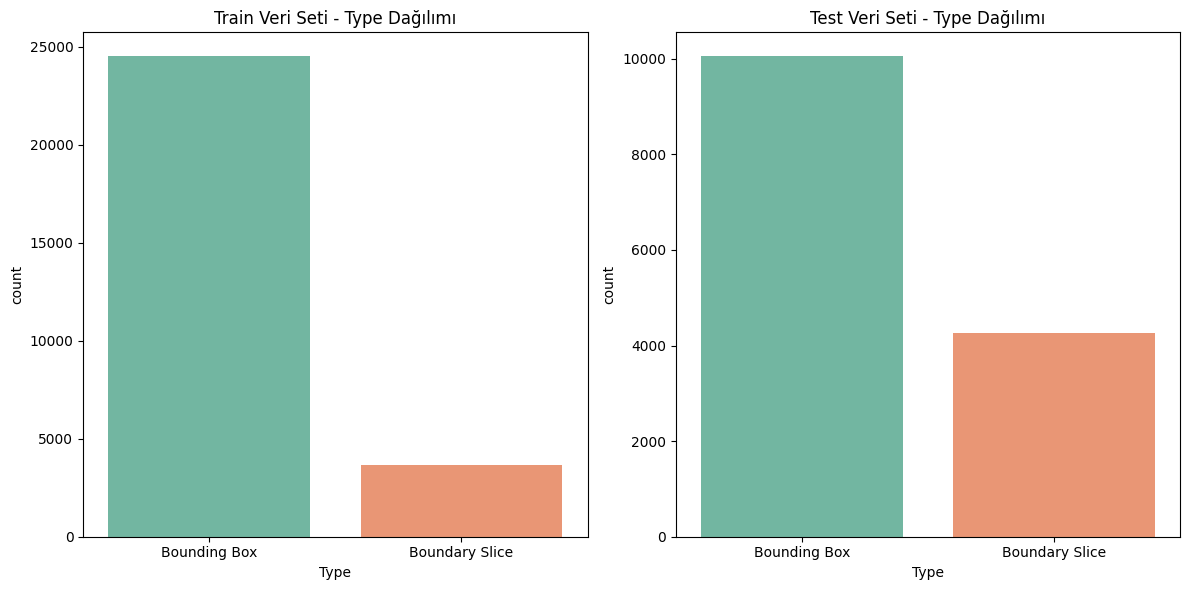

In [22]:
# Bounding Box annotasyonlarının  ve Boundary Slice annotasyonlarının dağılımına bakalım. Test ve train veri setleri için karşılaştıralım.
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.countplot(x='Type', data=dataTrain,order=dataTrain['Type'].value_counts().index,palette='Set2')
plt.title('Train Veri Seti - Type Dağılımı')
plt.subplot(1, 2, 2)
sns.countplot(x='Type', data=dataTest,order=dataTest['Type'].value_counts().index,palette='Set2')
plt.title('Test Veri Seti - Type Dağılımı')
plt.tight_layout()
plt.show()  

In [25]:
from src.bb_boyut_grafigi import bbox_frame


train_bb = bbox_frame(sheets["TRAIININGDATA"])
comp_bb = bbox_frame(sheets["COMPETITIONDATA"])
print(f"Eğitim BB sayısı: {len(train_bb):,}")
print(f"Yarışma BB sayısı: {len(comp_bb):,}")
 

Eğitim BB sayısı: 24,495
Yarışma BB sayısı: 10,052

Grafik kaydedildi: D:\makale-pdf\Proje\abdomen\Analiz_Sonuclari\grafikler\bb_boyut_dagilimi.png

Sınıf bazında medyan √alan (piksel) — Eğitim
                                      count  median_w  median_h  median_sqrt_area
Class                                                                            
ureteral stone                          291       9.0      10.0               9.8
Calcified diverticulum                   36      13.0      11.5              12.0
Kidney stone                           1114      12.0      12.0              12.1
Gallbladder stone                      1340      25.0      22.0              23.5
Compatible with acute appendicitis       54      33.0      25.0              27.2
Abdominal aortic dissection             806      32.0      33.0              33.5
Compatible with acute diverticulitis     18      31.0      42.5              36.4
Abdominal Aorta                          14      58.0      58.0     

In [27]:
# ---- SAYISAL ÖZET ----
print("\n" + "=" * 60)
print("Sınıf bazında medyan √alan (piksel) — Eğitim")
print("=" * 60)
summary = (train_bb.groupby("Class")
           .agg(count=("area", "size"),
                median_w=("w", "median"),
                median_h=("h", "median"),
                median_sqrt_area=("sqrt_area", "median"))
           .round(1)
           .sort_values("median_sqrt_area"))
print(summary.to_string())
 


Sınıf bazında medyan √alan (piksel) — Eğitim
                                      count  median_w  median_h  median_sqrt_area
Class                                                                            
ureteral stone                          291       9.0      10.0               9.8
Calcified diverticulum                   36      13.0      11.5              12.0
Kidney stone                           1114      12.0      12.0              12.1
Gallbladder stone                      1340      25.0      22.0              23.5
Compatible with acute appendicitis       54      33.0      25.0              27.2
Abdominal aortic dissection             806      32.0      33.0              33.5
Compatible with acute diverticulitis     18      31.0      42.5              36.4
Abdominal Aorta                          14      58.0      58.0              58.0
Compatible with acute cholecystitis    4925      57.0      63.0              59.9
Compatible with acute pancreatitis     6922      79.

In [28]:
CLASSES= train_bb.groupby("Class")["sqrt_area"].median().sort_values().index.tolist()

In [29]:
# # Gösterilecek 10 patoloji sınıfı (eğitim setindeki tüm BB sınıfları)
# CLASSES = [
#     "Abdominal aortic aneurysm",
#     "Abdominal aortic dissection",
#     "Compatible with acute pancreatitis",
#     "Compatible with acute cholecystitis",
#     "Compatible with acute appendicitis",
#     "Compatible with acute diverticulitis",
#     "Calcified diverticulum",
#     "Kidney stone",
#     "ureteral stone",
#     "Gallbladder stone",
# ]


In [30]:
dataTrain["Class"].value_counts()

Class
Abdominal aortic aneurysm               8983
Compatible with acute pancreatitis      7128
Compatible with acute cholecystitis     5159
Gallbladder stone                       1439
Kidney stone                            1149
Abdominal aortic dissection              806
Abdominal Aorta                          733
Kidney-Bladder                           608
Pancreas                                 502
Gall bladder                             439
Colon                                    411
appendix                                 338
ureteral stone                           321
Compatible with acute appendicitis        60
Calcified diverticulum                    38
Compatible with acute diverticulitis      20
Name: count, dtype: int64

In [31]:
all_bb = pd.concat([sheets["TRAIININGDATA"], sheets["COMPETITIONDATA"]])
all_bb = all_bb[all_bb["Type"] == "Bounding Box"].reset_index(drop=True)



In [ ]:

# # Geçersiz BB'leri bulunuz
# invalid_mask = ~all_bb["Data"].apply(is_valid_bbox)
# invalid_count = invalid_mask.sum()
# print(f"\n⚠️  Geçersiz BB sayısı: {invalid_count}")


# if invalid_count > 0:
#     print("\nGeçersiz BB örnekleri:")
#     print(all_bb.loc[invalid_mask, ["Case Number", "Image Id", "Class", "Data"]].head(10))


# # Geçersiz BB'leri çıkart
# all_bb = all_bb[~invalid_mask].reset_index(drop=True)
# print(f"✓ Filtrelemeden sonra toplam BB: {len(all_bb)}")

In [32]:
CLASSES

['ureteral stone',
 'Calcified diverticulum',
 'Kidney stone',
 'Gallbladder stone',
 'Compatible with acute appendicitis',
 'Abdominal aortic dissection',
 'Compatible with acute diverticulitis',
 'Abdominal Aorta',
 'Compatible with acute cholecystitis',
 'Compatible with acute pancreatitis',
 'Abdominal aortic aneurysm']

In [ ]:

# ---- ÇİZİM ----
from src.sinif_ornekleri_bb import dicom_path_for, load_hu, window
from src.bb_boyut_grafigi import parse_bbox


CLASSES1 = CLASSES.copy()[0:6]  # orijinal sıralamayı korumak için
plt.rcParams["font.family"] = "DejaVu Sans"
fig, axes = plt.subplots(2, len(CLASSES1) // 2, figsize=(18, 8))
axes = axes.flatten()

for i, cls in enumerate(CLASSES1):
    ax = axes[i]
    sub = all_bb[all_bb["Class"] == cls].reset_index(drop=True)
    if len(sub) == 0:
        ax.text(0.5, 0.5, f"{cls}\n(örnek yok)", ha="center", va="center")
        ax.axis("off")
        continue

    # Medyan alanlı BB'yi seç (aşırı küçük/büyük olmasın)
    sub = sub.assign(area=sub["Data"].apply(
        lambda s: (lambda b: (b[2]-b[0])*(b[3]-b[1]))(parse_bbox(s))))
    sub = sub.sort_values("area").reset_index(drop=True)
    row = sub.iloc[len(sub) // 2]        # medyan
    x1, y1, x2, y2 = parse_bbox(row["Data"])

    try:
        dpath = dicom_path_for(int(row["Case Number"]), int(row["Image Id"]))
        hu = load_hu(dpath)
        # 3 kanallı pencereler (model eğitiminde kullanılanlar)
        img_ch1 = window(hu, level=40,  width=400)    # soft_tissue (abdomen)
        img_ch2 = window(hu, level=30,  width=150)    # liver
        img_ch3 = window(hu, level=450, width=1500)   # calcified
        img = np.stack([img_ch1, img_ch2, img_ch3], axis=0)  # (3, H, W)
    except Exception as exc:
        ax.text(0.5, 0.5, f"{cls}\nhata: {exc}", ha="center", va="center",
                fontsize=8)
        ax.axis("off")
        continue

    # 3 kanallı görüntüyü göster (soft_tissue kanalı görünür, en iyi kontrastı sağlar)
    ax.imshow(img[0], cmap="gray", vmin=0, vmax=1)
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                             linewidth=2.2, edgecolor="#ff1744",
                             facecolor="none")
    ax.add_patch(rect)
    # Etiket: sol-üst köşede kırmızı arka plan
    ax.text(x1, max(y1 - 6, 10), cls, fontsize=9, color="white",
            bbox=dict(facecolor="#ff1744", alpha=0.85, pad=2, edgecolor="none"))
    ax.set_title(f"vaka={row['Case Number']}  kesit={row['Image Id']}  "
                 f"alan={int(row['area'])} px²", fontsize=9)
    ax.axis("off")

plt.suptitle("TR_ABDOMEN_RAD_EMERGENCY — Sınıf Başına BB Overlay Örnekleri "
             "(W=400, L=40 abdomen penceresi)",
             fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()

# OUT.parent.mkdir(parents=True, exist_ok=True)
# plt.savefig(OUT, dpi=150, bbox_inches="tight")
# plt.close()
# print(f"Grafik kaydedildi: {OUT}")